<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/pca_image_compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

image.jpg not found, downloading a sample image...


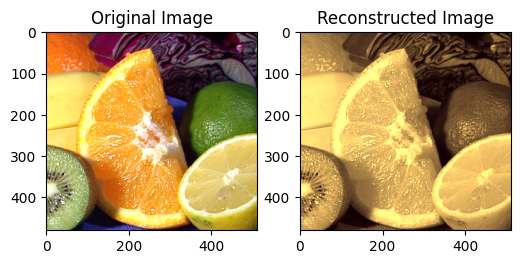

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib import image as mpimg
import requests
from io import BytesIO
from PIL import Image

# Load a sample image (use a local image file or download one)
# Download a sample image if 'image.jpg' is not found
try:
    image_path = "C:/Users/OMOKE/Pictures/download (26)1.jpg"
    image = mpimg.imread(image_path)
except FileNotFoundError:
    print("image.jpg not found, downloading a sample image...")
    # Using a more direct URL for a JPEG image from a reliable source
    image_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/fruits.jpg"
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)) # Use PIL to open the image
    image = np.array(image) # Convert PIL image to numpy array

image = image / 155.0  # Normalize pixel values to range [0, 1]
h, w, c = image.shape

# Reshape the image for PCA (flatten the image)
image_reshaped = image.reshape((h * w, c))

# Apply PCA for image compression
n_components = 0.2  # Adjusted to max of 3 for RGB image features
pca = PCA(n_components=n_components)
image_pca = pca.fit_transform(image_reshaped)

# Reconstruct the image using the compressed PCA data
image_reconstructed = pca.inverse_transform(image_pca)
image_reconstructed = np.reshape(image_reconstructed, (h, w, c))

# Plot the original and compressed images
plt.figure(figsize=(6, 4))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image)
plt.subplot(1, 2, 2)
plt.title('Reconstructed Image')
plt.imshow(image_reconstructed)
plt.show()